In [1]:
%matplotlib inline
import qiskit
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit , QuantumRegister , ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram , plot_state_qsphere , plot_bloch_multivector , plot_state_city
from qiskit.quantum_info import Statevector , random_statevector
from qiskit import transpile

In [2]:
# compute logical and gate
def compute_and(qc,x,y,A):
  qc.cx(x,A)
  qc.cx(y,A)
  qc.cx(A,y)
  qc.cx(A,x)

  qc.tdg(x)
  qc.tdg(y)
  qc.t(A)

  qc.cx(A,y)
  qc.cx(A,x)

  qc.h(A)
  qc.s(A)


In [3]:
# uncompute logical and gate
def uncompute_and(qc,x,y,A):
  qc.sdg(A)
  qc.h(A)

  qc.cx(A,y)
  qc.cx(A,x)

  qc.t(x)
  qc.t(y)
  qc.tdg(A)

  qc.cx(A,y)
  qc.cx(A,x)

  qc.cx(y,A)
  qc.cx(x,A)


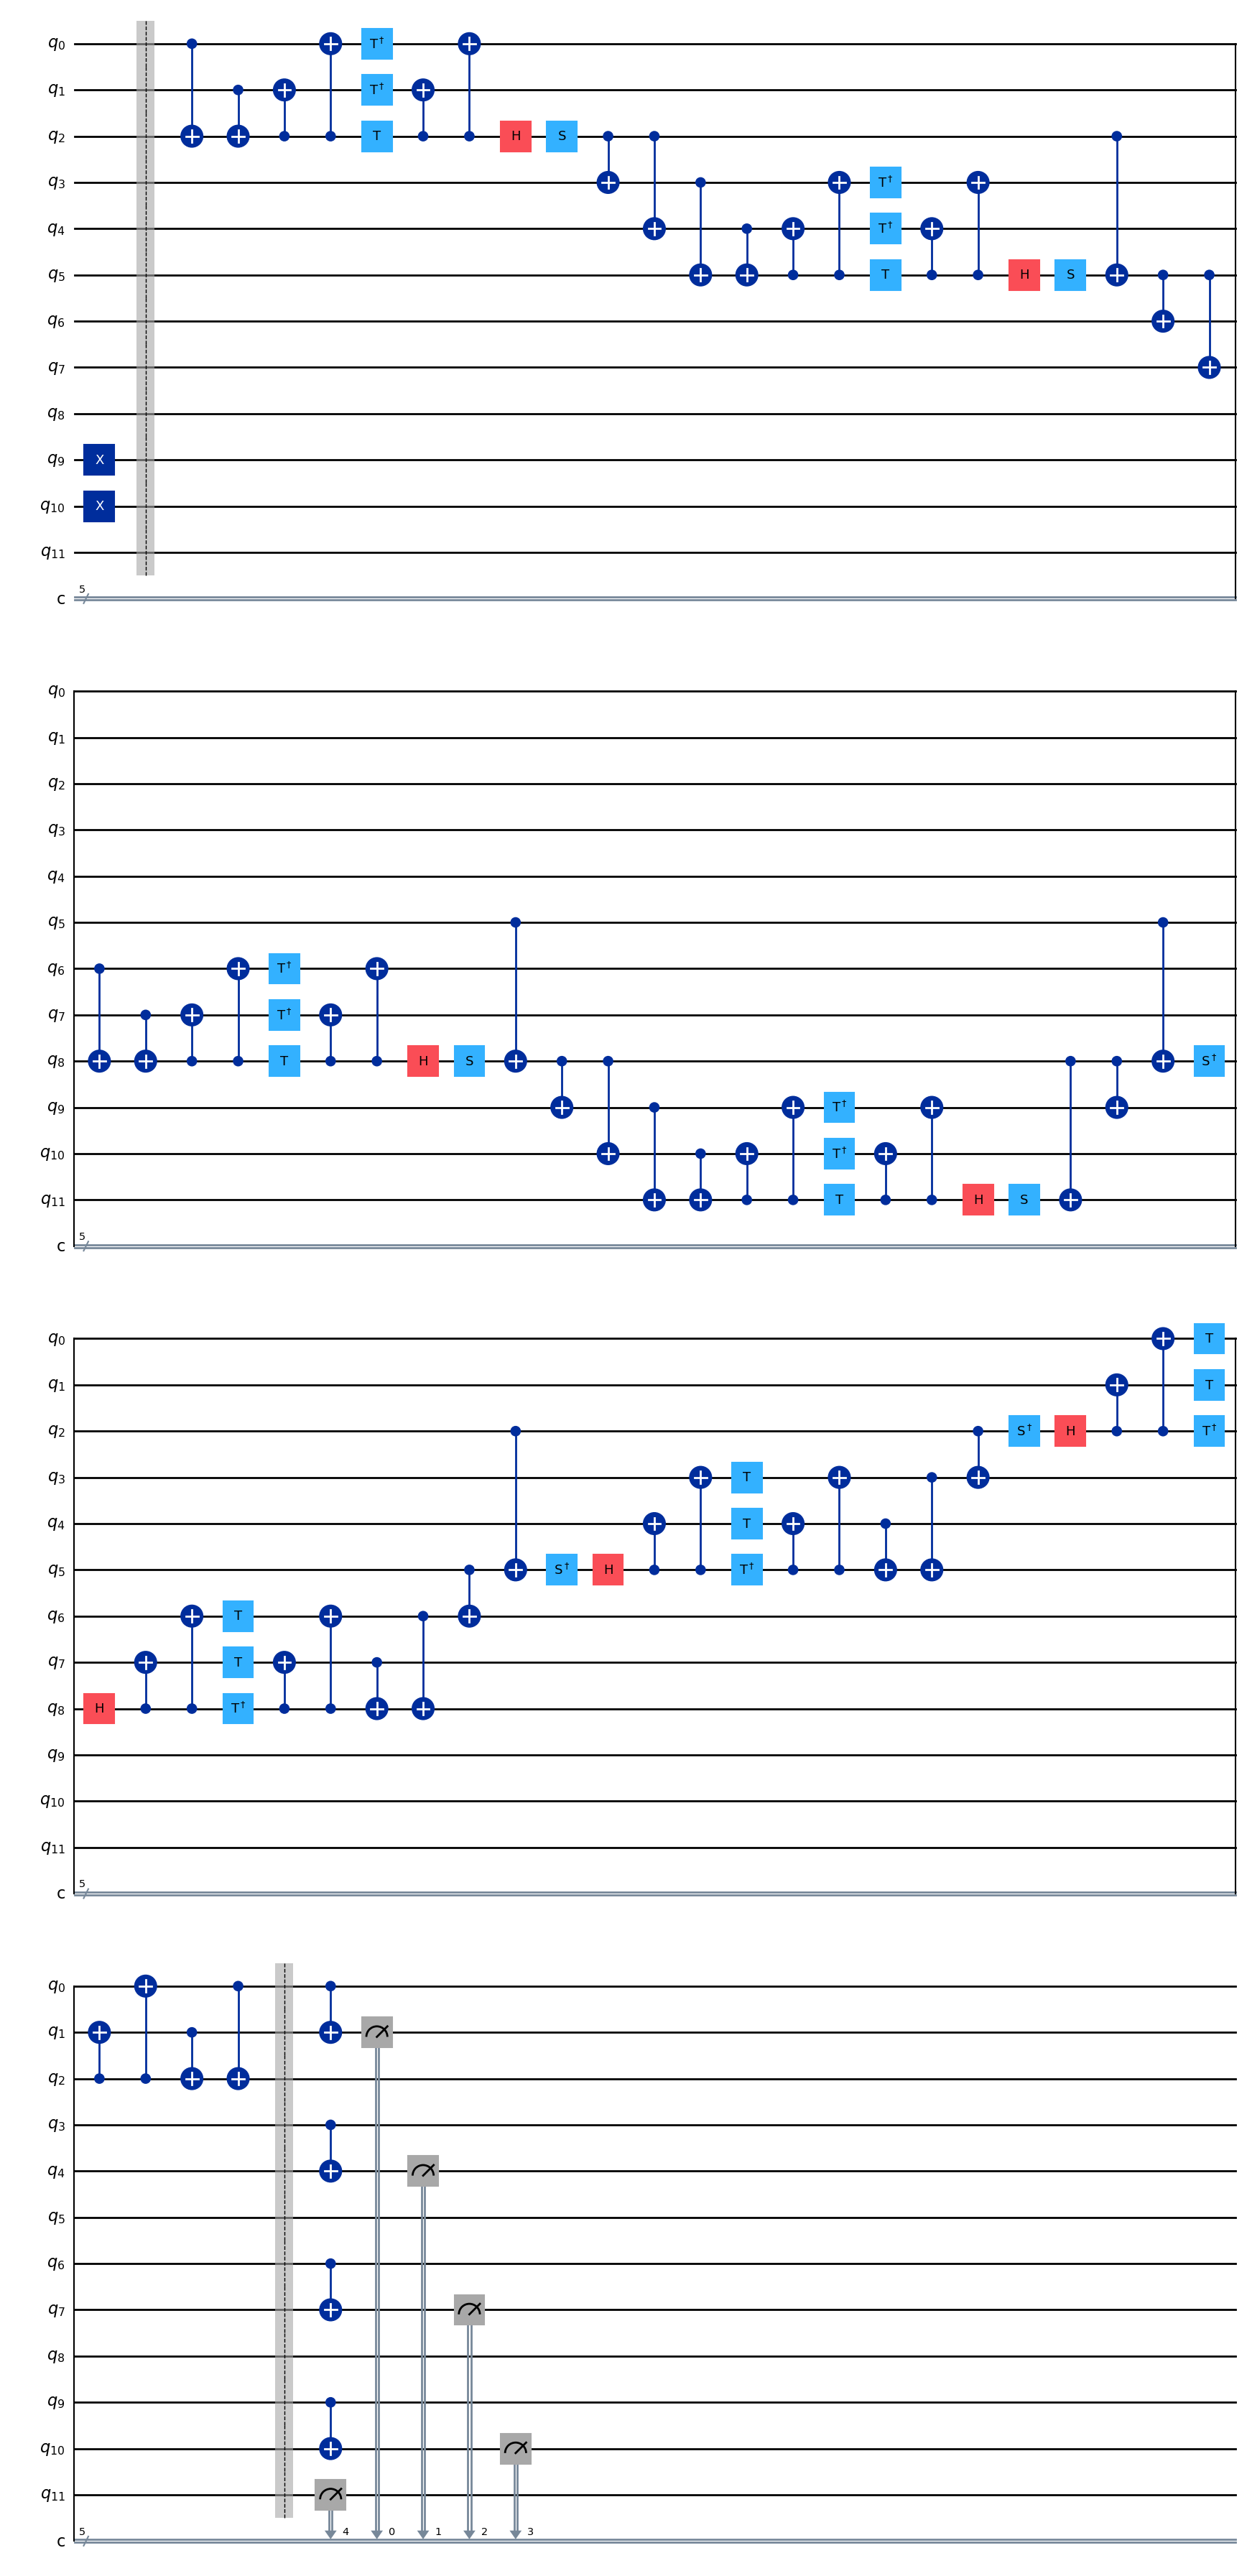

In [7]:
qc = QuantumCircuit(12,5)

qc.x(9)
qc.x(10)

qc.barrier()

compute_and(qc,0,1,2)
qc.cx(2,3)
qc.cx(2,4)

compute_and(qc,3,4,5)
qc.cx(2,5)
qc.cx(5,6)
qc.cx(5,7)

compute_and(qc,6,7,8)
qc.cx(5,8)
qc.cx(8,9)
qc.cx(8,10)

compute_and(qc,9,10,11)
qc.cx(8,11)



qc.cx(8,9)
qc.cx(5,8)
uncompute_and(qc,6,7,8)

qc.cx(5,6)
qc.cx(2,5)
uncompute_and(qc,3,4,5)

qc.cx(2,3)
uncompute_and(qc,0,1,2)

qc.barrier()

qc.cx(0,1)
qc.cx(3,4)
qc.cx(6,7)
qc.cx(9,10)

# measurements
qc.measure(1,0)
qc.measure(4,1)
qc.measure(7,2)
qc.measure(10,3)
qc.measure(11,4)

qc.draw('mpl')




Circuit Diagram:



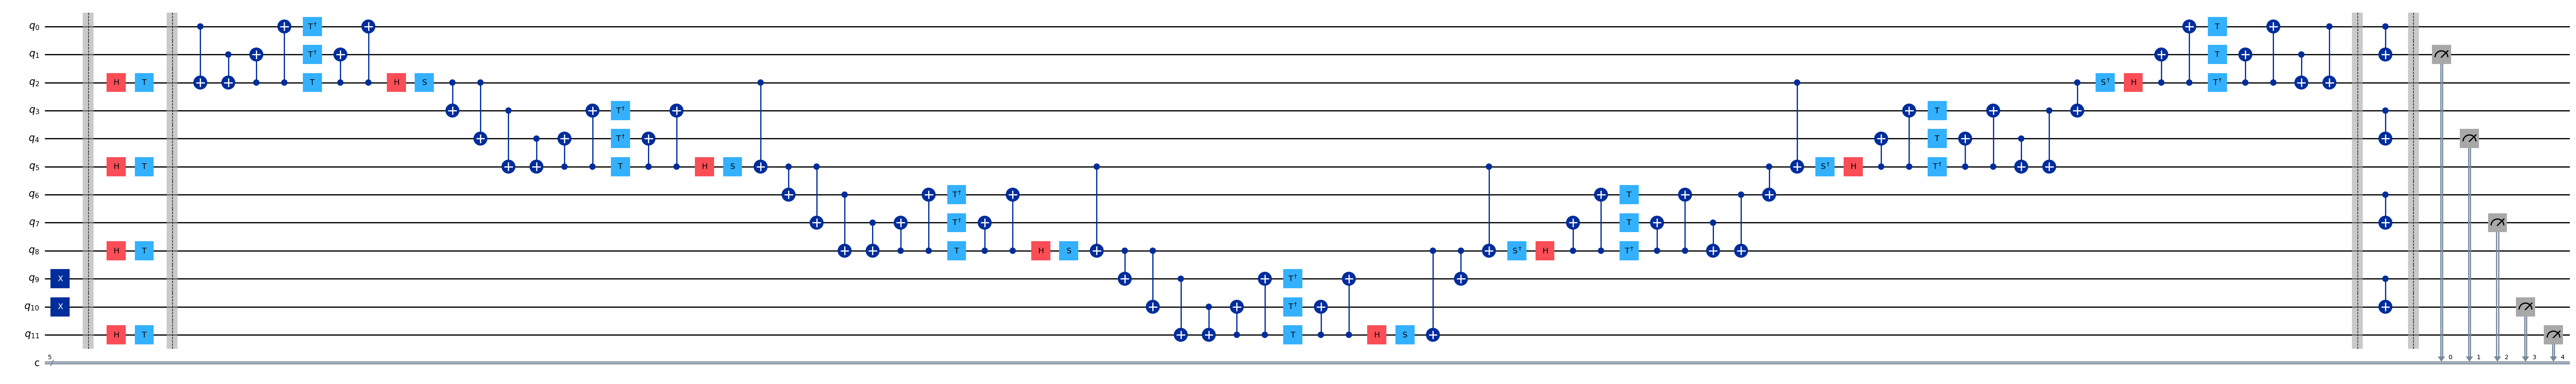


Measurement Counts:

{'11000': 462, '10000': 6307, '10010': 712, '10100': 736, '11100': 189, '10011': 150, '10001': 422, '10110': 203, '11001': 29, '01000': 215, '00000': 213, '01100': 42, '11110': 32, '10111': 23, '00010': 30, '11011': 10, '11010': 55, '10101': 42, '11111': 6, '11101': 15, '01010': 25, '00100': 35, '00011': 5, '00001': 8, '01110': 8, '01001': 13, '00110': 5, '01011': 4, '00101': 4}


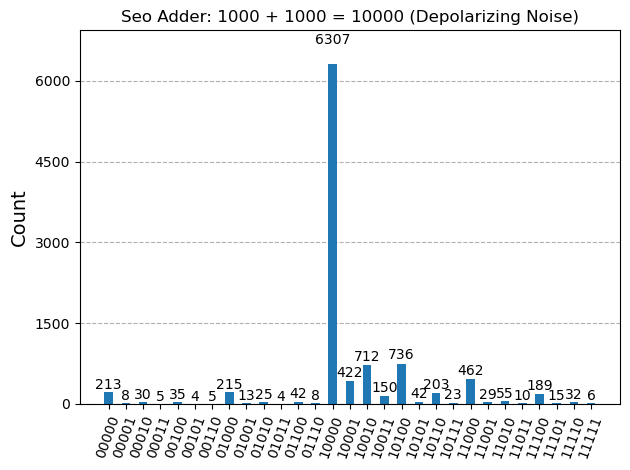


RESULTS (SEO ADDER)

Correct Output: 10000

Correct Counts: 6307

Error Rate (ER): 36.92999999999999

Mean Error Distance: 2.1139

NMED: 0.07046333333333334

MRED: 0.13211875

Success Rate: 0.6307



In [11]:
%matplotlib inline
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# =====================================================
# SEO ADDER LOGICAL GATES
# =====================================================
def gate_A(qc, A):
    qc.h(A)
    qc.t(A)

def compute_and(qc, x, y, A):
    qc.cx(x, A)
    qc.cx(y, A)
    qc.cx(A, y)
    qc.cx(A, x)
    qc.tdg(x)
    qc.tdg(y)
    qc.t(A)
    qc.cx(A, y)
    qc.cx(A, x)
    qc.h(A)
    qc.s(A)

def uncompute_and(qc, x, y, A):
    qc.sdg(A)
    qc.h(A)
    qc.cx(A, y)
    qc.cx(A, x)
    qc.t(x)
    qc.t(y)
    qc.tdg(A)
    qc.cx(A, y)
    qc.cx(A, x)
    qc.cx(y, A)
    qc.cx(x, A)


# =====================================================
# 4-BIT SEO ADDER
# TEST CASE:
# 1000 + 1000 = 10000
# =====================================================

qc = QuantumCircuit(12, 5)

# INPUT: A = 1000 (Bit 3), B = 1000 (Bit 3)
# Qubit 9 maps to A_3, Qubit 10 maps to B_3
qc.x(9)
qc.x(10)

qc.barrier()

# -----------------------------------------------------
# FIX: PREPARE ANCILLAS IN |A> STATE
# -----------------------------------------------------
gate_A(qc, 2)
gate_A(qc, 5)
gate_A(qc, 8)
gate_A(qc, 11)

qc.barrier()

# Forward operations (Compute)
compute_and(qc, 0, 1, 2)
qc.cx(2, 3)
qc.cx(2, 4)

compute_and(qc, 3, 4, 5)
qc.cx(2, 5)
qc.cx(5, 6)
qc.cx(5, 7)

compute_and(qc, 6, 7, 8)
qc.cx(5, 8)
qc.cx(8, 9)
qc.cx(8, 10)

compute_and(qc, 9, 10, 11)
qc.cx(8, 11)

# Reverse operations (Uncompute)
qc.cx(8, 9)
qc.cx(5, 8)
uncompute_and(qc, 6, 7, 8)

qc.cx(5, 6)
qc.cx(2, 5)
uncompute_and(qc, 3, 4, 5)

qc.cx(2, 3)
uncompute_and(qc, 0, 1, 2)

qc.barrier()

# Final sums
qc.cx(0, 1)
qc.cx(3, 4)
qc.cx(6, 7)
qc.cx(9, 10)
qc.barrier()
# =====================================================
# MEASUREMENTS
# =====================================================

qc.measure(1, 0)
qc.measure(4, 1)
qc.measure(7, 2)
qc.measure(10, 3)
qc.measure(11, 4)

# ====================================================
# DRAW CIRCUIT
# ====================================================

print("\nCircuit Diagram:\n")
qc.draw('mpl', fold=-1)
plt.show()

# ====================================================
# DEPOLARIZING NOISE MODEL
# ====================================================

# 1-Qubit Error (p = 0.005)
error_1 = depolarizing_error(0.005, 1)

# 2-Qubit Error (p = 0.01)
error_2 = depolarizing_error(0.01, 2)

noise_model = NoiseModel()

# Apply noise to X and single-qubit gates
noise_model.add_all_qubit_quantum_error(
    error_1, 
    ['x', 'h', 's', 'sdg', 't', 'tdg']
)

# Apply noise to CX (2-qubit) gates
noise_model.add_all_qubit_quantum_error(
    error_2, 
    ['cx']
)

# ====================================================
# CREATE NOISY SIMULATOR & TRANSPILE
# ====================================================

sim = AerSimulator(noise_model=noise_model)
compiled = transpile(qc, sim)

# ====================================================
# RUN SIMULATION
# ====================================================

shots = 10000

result = sim.run(
    compiled,
    shots=shots
).result()

counts = result.get_counts()

# ====================================================
# SHOW COUNTS & PLOT HISTOGRAM
# ====================================================

print("\nMeasurement Counts:\n")
print(counts)

plot_histogram(counts, title="Seo Adder: 1000 + 1000 = 10000 (Depolarizing Noise)")
plt.show()

# ====================================================
# ERROR METRICS CALCULATION
# ====================================================

correct_output = '10000'
correct_decimal = 16

D = 30  # Maximum possible distance for 4-bit addition

# Error Rate (ER)
correct_counts = counts.get(correct_output, 0)
ER = 1 - (correct_counts / shots)

# Calculate ED, NMED, MRED
total_ED = 0
total_relative_ED = 0

for output, freq in counts.items():
    noisy_decimal = int(output, 2)
    ED = abs(correct_decimal - noisy_decimal)
    total_ED += ED * freq

    if correct_decimal != 0:
        total_relative_ED += (ED / correct_decimal) * freq

mean_ED = total_ED / shots
NMED = mean_ED / D
MRED = total_relative_ED / shots
success_rate = correct_counts / shots

# ====================================================
# DISPLAY RESULTS
# ====================================================

print("\n===================================")
print("RESULTS (SEO ADDER)")
print("===================================")
print(f"\nCorrect Output: {correct_output}")
print(f"\nCorrect Counts: {correct_counts}")
print(f"\nError Rate (ER): {ER*100}")
print(f"\nMean Error Distance: {mean_ED}")
print(f"\nNMED: {NMED}")
print(f"\nMRED: {MRED}")
print(f"\nSuccess Rate: {success_rate}")
print("\n===================================")